In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


In [3]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''

print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



In [5]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []

for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_len,
    padding='pre'
)

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


In [7]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_history = rnn_model.fit(
    X,
    y,
    epochs=200,
    verbose=0
)

print("Vanilla RNN Training Completed")

D:\Anaconda\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN Training Completed


In [9]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_history = lstm_model.fit(
    X,
    y,
    epochs=200,
    verbose=0
)

print("LSTM Training Completed")

LSTM Training Completed


In [11]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

gru_history = gru_model.fit(
    X,
    y,
    epochs=200,
    verbose=0
)

print("GRU Training Completed")

GRU Training Completed


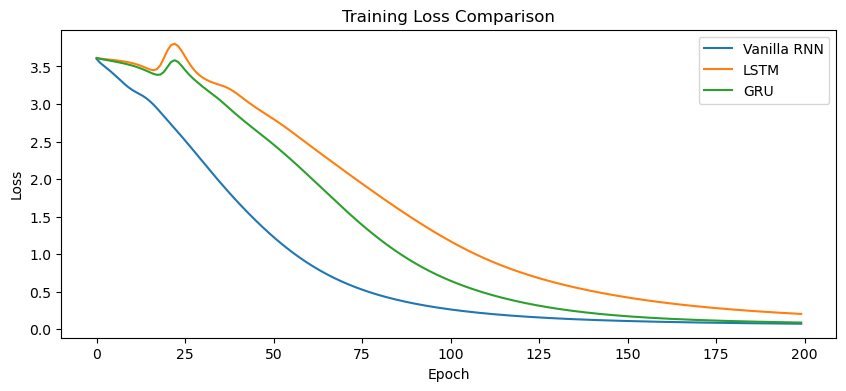

In [13]:
plt.figure(figsize=(10,4))

plt.plot(rnn_history.history['loss'], label='Vanilla RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()

plt.show()

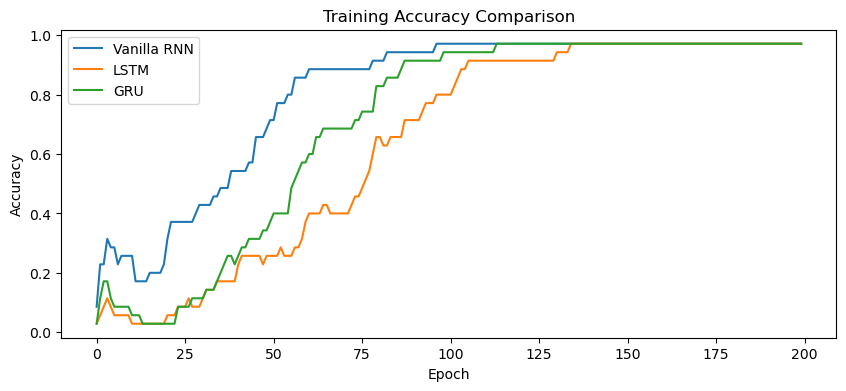

In [15]:
plt.figure(figsize=(10,4))

plt.plot(rnn_history.history['accuracy'], label='Vanilla RNN')
plt.plot(lstm_history.history['accuracy'], label='LSTM')
plt.plot(gru_history.history['accuracy'], label='GRU')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Comparison")
plt.legend()

plt.show()

In [17]:
def generate_text(model, seed_text, next_words=5):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_len-1,
            padding='pre'
        )

        predicted = np.argmax(
            model.predict(token_list, verbose=0),
            axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

In [19]:
print("RNN :")
print(generate_text(rnn_model, "deep learning", 10))

print()

print("LSTM :")
print(generate_text(lstm_model, "deep learning", 10))

print()

print("GRU :")
print(generate_text(gru_model, "deep learning", 10))

RNN :
deep learning models can generate meaningful sentences dependencies word sequential data simpler

LSTM :
deep learning models can generate meaningful sentences sentences sentences sentences sentences word

GRU :
deep learning is transforming artificial intelligence intelligence intelligence intelligence intelligence generation models


In [21]:
print("Final Training Results\n")

print("Vanilla RNN")
print("Loss :", round(rnn_history.history['loss'][-1],4))
print("Accuracy :", round(rnn_history.history['accuracy'][-1]*100,2), "%")

print()

print("LSTM")
print("Loss :", round(lstm_history.history['loss'][-1],4))
print("Accuracy :", round(lstm_history.history['accuracy'][-1]*100,2), "%")

print()

print("GRU")
print("Loss :", round(gru_history.history['loss'][-1],4))
print("Accuracy :", round(gru_history.history['accuracy'][-1]*100,2), "%")

Final Training Results

Vanilla RNN
Loss : 0.0743
Accuracy : 97.14 %

LSTM
Loss : 0.2048
Accuracy : 97.14 %

GRU
Loss : 0.09
Accuracy : 97.14 %
